# **Домашнее задание 7: Fraud Detection Competition**

Добро пожаловать на финальное домашнее задание курса! Домашнее задание направлено на систематизацию всех знаний, полученных в процессе учебы.

В нём Вы потренируетесь применять навыки построения пайплайнов машинного обучения, приобретенные в курсе от точки разведочного анализа данных до построения и валидации моделей машинного обучения.

## **Задача**
**Вы будете решать задачу определения фрода:**

https://www.kaggle.com/competitions/fraud-detection-24

**Вам нужно будет:**
- в jupyter notebook провести исследование данных;
- в нём же построить модели и оценить их качество;
- отправить посылку на Kaggle.

Более подробное описание шагов - в ноутбуке ниже.

## **Оценивание и баллы**
- В EDA и во всей работе будут оцениваться полнота и **выводы**;
- При обучении моделей старайтесь обоснованно подходить к их выбору, избегая простого перебора;

**Максимальный балл** - 10 (+ бонусы за Kaggle, см. ниже).


Мягкий дедлайн (окончание соревнования на Kaggle): **15 марта 23:59**


# **Базовое решение и пример формирования файла под submission**


In [1]:
# !wget --no-check-certificate 'https://www.dropbox.com/scl/fi/wo7ikp62gmivym1z690mt/train_transaction.csv?rlkey=6h1asd0tit8iwwtfu9dpatoxk&st=wpbf9jme&dl=0' -O train_transaction.csv
# !wget --no-check-certificate 'https://www.dropbox.com/scl/fi/xnz3rximj230t7fah8bek/train_identity.csv?rlkey=wrtxpgi5ifea063humoxa61qk&st=0oi753d6&dl=0' -O train_identity.csv
# !wget --no-check-certificate 'https://www.dropbox.com/scl/fi/7tvqgk1hmgzc57t83tr1y/test_transaction.csv?rlkey=tltolh9xqa1c1xgjwnur3dv4y&st=rgt90tji&dl=0' -O test_transaction.csv
# !wget --no-check-certificate 'https://www.dropbox.com/scl/fi/xjgckn314vbgfpgzeiz3a/test_identity.csv?rlkey=orim3gfj15t49hs46gxhid8ky&st=gn51fozl&dl=0' -O test_identity.csv
# !wget --no-check-certificate 'https://www.dropbox.com/scl/fi/n275m43mp74bf4fpsidu7/sample_submission.csv?rlkey=8h7qcl07qa67u07129ewkiizr&st=2vcj5vr5&dl=0' -O sample_submission.csv

In [2]:
# скачиваем данные с Kagle
!pip install kaggle -q
!mkdir -p ~/.kaggle

!mv /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!ls -l ~/.kaggle/

!kaggle competitions download -c fraud-detection-24 -p data

!unzip -o data/fraud-detection-24.zip -d data

mv: cannot stat '/content/kaggle.json': No such file or directory
total 4
-rw------- 1 root root 71 Mar 14 19:41 kaggle.json
fraud-detection-24.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  data/fraud-detection-24.zip
  inflating: data/sample_submission.csv  
  inflating: data/test_identity.csv  
  inflating: data/test_transaction.csv  
  inflating: data/train_identity.csv  
  inflating: data/train_transaction.csv  


In [3]:
!pip install catboost -q

In [4]:
!pip install optuna

In [5]:
from catboost import CatBoostClassifier
import pandas as pd
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

from joblib import dump, load

import optuna
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import cross_val_score
from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA, TruncatedSVD

In [6]:
def reduce_mem_usage(df):
    NAlist = []
    for col in tqdm(df.columns):
        if df[col].dtype != object:

            if not np.isfinite(df[col]).all():
                NAlist.append(col)
                df[col] = df[col].fillna(df[col].min() - 1)

            if np.all(np.abs(df[col] - df[col].round()) < 1e-6):
                rounded = df[col].round()
                rmin = rounded.min()
                rmax = rounded.max()
                if rmin >= 0:
                    if rmax < 255:
                        df[col] = rounded.astype(np.uint8)
                    elif rmax < 65535:
                        df[col] = rounded.astype(np.uint16)
                    elif rmax < 4294967295:
                        df[col] = rounded.astype(np.uint32)
                    else:
                        df[col] = rounded.astype(np.uint64)
                else:
                    if rmin > np.iinfo(np.int8).min and rmax < np.iinfo(np.int8).max:
                        df[col] = rounded.astype(np.int8)
                    elif rmin > np.iinfo(np.int16).min and rmax < np.iinfo(np.int16).max:
                        df[col] = rounded.astype(np.int16)
                    elif rmin > np.iinfo(np.int32).min and rmax < np.iinfo(np.int32).max:
                        df[col] = rounded.astype(np.int32)
                    elif rmin > np.iinfo(np.int64).min and rmax < np.iinfo(np.int64).max:
                        df[col] = rounded.astype(np.int64)
            else:
                df[col] = df[col].astype(np.float32)
    return df, NAlist

In [7]:
INPUT_DIR = 'data'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))
sample_submission = pd.read_csv(os.path.join(INPUT_DIR, 'sample_submission.csv'))

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
del train_transaction, train_identity
df_train, df_train_NAlist = reduce_mem_usage(df_train)

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')
del test_transaction, test_identity
df_test, df_test_NAlist = reduce_mem_usage(df_test)

100%|██████████| 433/433 [00:01<00:00, 230.47it/s]


In [8]:
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 432), (172981, 431))

In [9]:
object_cols = []
for idx, col in tqdm(enumerate(df_train.columns.drop('isFraud'))):
    if df_train[col].dtype == 'O':
      object_cols.append(idx)

431it [00:00, 40889.03it/s]


In [10]:
X_train = df_train.drop('isFraud', axis=1)
X_train = X_train.fillna('')
y_train = df_train['isFraud'].values

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, object_cols, )

Learning rate set to 0.5
0:	learn: 0.2082395	total: 1.47s	remaining: 2.94s
1:	learn: 0.1356356	total: 2.6s	remaining: 1.3s
2:	learn: 0.1178118	total: 4.12s	remaining: 0us


In [11]:
predictions = cb.predict_proba(df_test.fillna(''))

In [12]:
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 0]})
sub.head()

,TransactionID,isFraud
0,3404559,0.991635
1,3404560,0.935909
2,3404561,0.914531
3,3404562,0.991635
4,3404563,0.970878


In [13]:
# Сохранение submission
sub.to_csv('submission_baseline.csv', index=False)

### **Примечания:**

**1. Оценка качества и Submission File**
- Ответом является число от 0 до 1, метрикой качества - AUC-ROC.
- Структура Submission File:
 - для каждого значения *TransactionID* в тестовых данных вы должны предсказать **вероятность** для столбца *isFraud*.
 - в файле у вас должно быть две колонки: `TransactionID` и`isFraud`  **для каждой транзакции в датасете**.

**2. Объем данных**

Поскольку набор данных объемный, могут быть проблемы с переполнением памяти в Collab. Для решения проблемы можете использовать функцию из [этого ноутбука](https://colab.research.google.com/drive/18u75eyFGEoyeWJ_MbsLkcPa6gv2tNI8G#scrollTo=V2L1Nl5CTMMl), разобравшись, что она делает с данными.

# **Задание 1 (2 балла)**

Проведите EDA (разведочный анализ данных):
* проанализируйте признаки, их особенности и связь с целевой переменной
* проанализируйте целевую переменную
* оцените степень попарной взаимосвязи признаков, а также связи признаков и целевой переменной
* по результатам исследований сделайте необходимую обработку данных (удаление дублей, работа с пропусками, с категориальными столбцами (если они есть), работа с аномалиями, другие преобразования признаков)

Важно, что EDA всегда сопровождается выводами - не забудьте об этом.

In [14]:
df_train.head()

,isFraud,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,0,68.5,W,13926,99,150,discover,142,credit,315,...,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,29.0,W,2755,404,150,mastercard,102,credit,325,...,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,59.0,W,4663,490,150,visa,166,debit,330,...,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,50.0,W,18132,567,150,mastercard,117,debit,476,...,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,50.0,H,4497,514,150,mastercard,102,credit,420,...,samsung browser 6.2,32,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


### 1.1. Проаналализируем признаки, их особенность и связь с целевой переменной

In [15]:
# категориальные признаки
categorical_columns = list(df_train.select_dtypes(include='object').columns)


Уникальные значения для ProductCD:
5


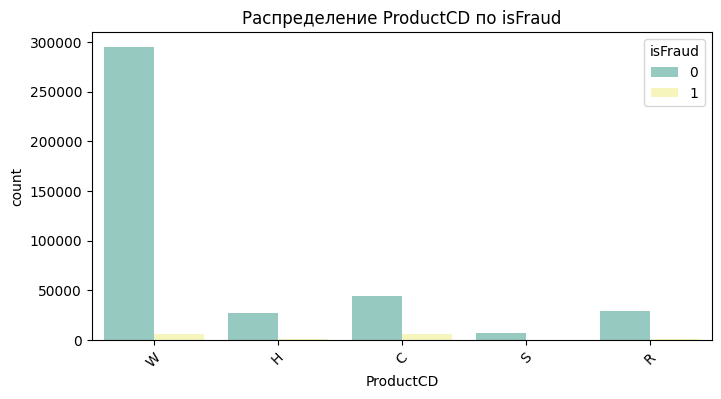


Уникальные значения для card4:
4


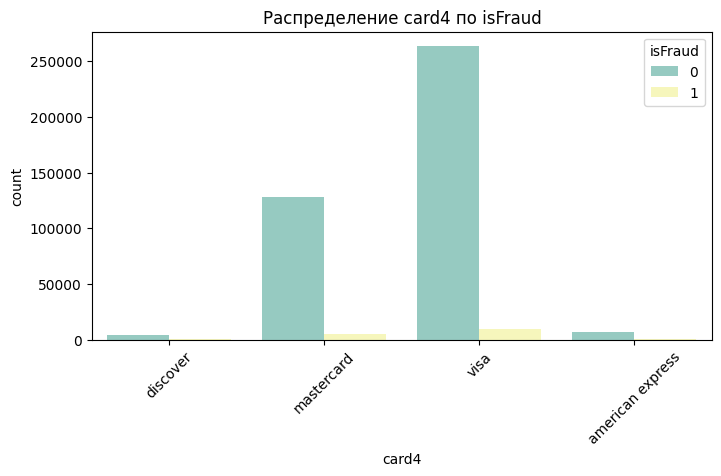


Уникальные значения для card6:
4


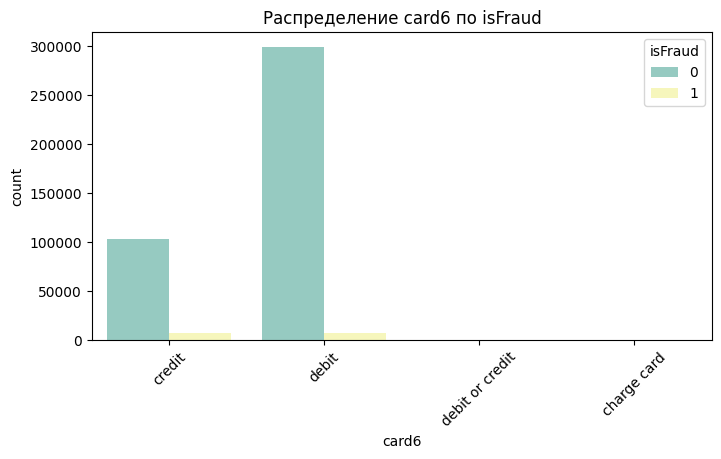


Уникальные значения для P_emaildomain:
59

Уникальные значения для R_emaildomain:
60

Уникальные значения для M1:
2


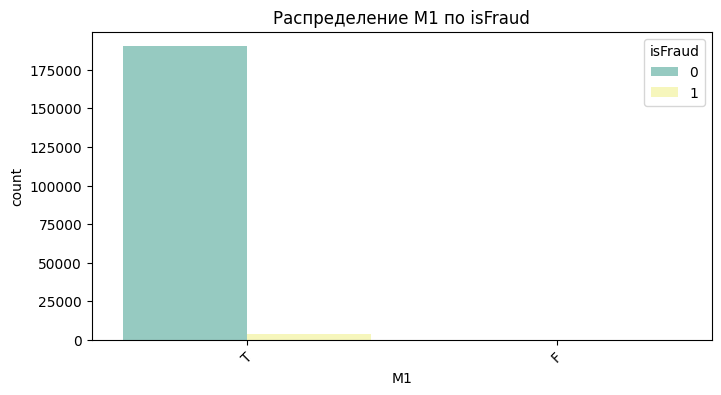


Уникальные значения для M2:
2


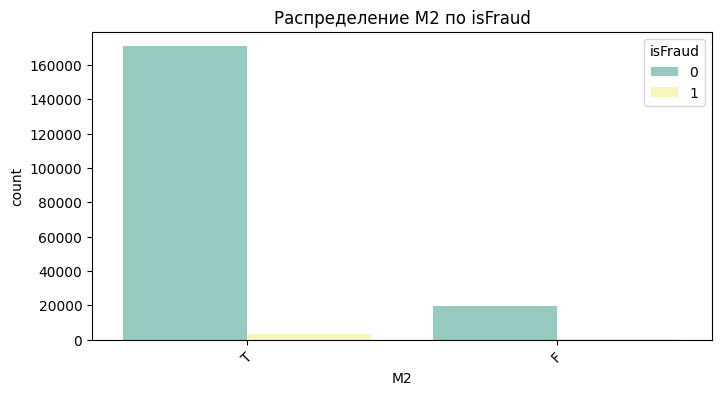


Уникальные значения для M3:
2


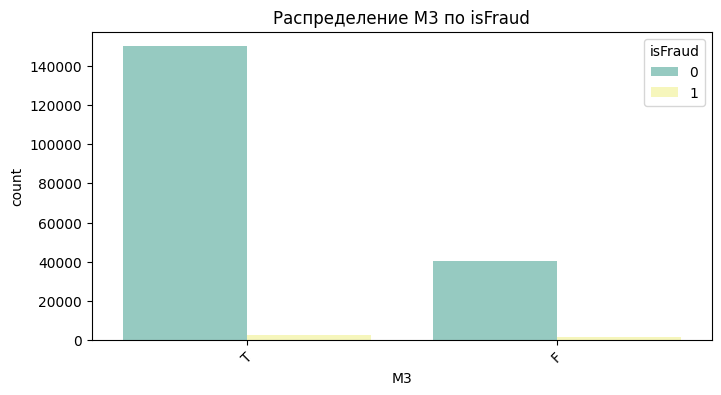


Уникальные значения для M4:
3


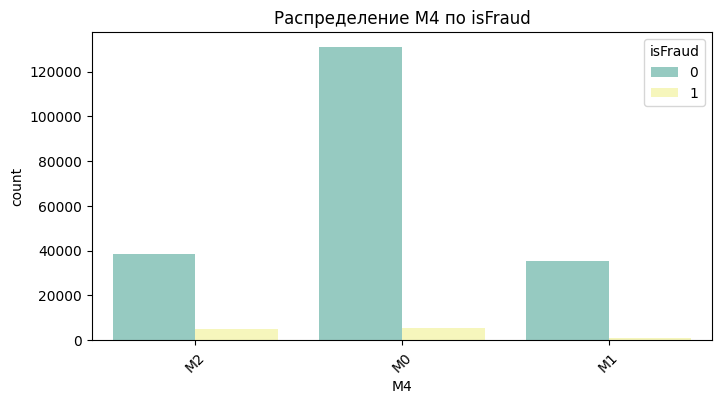


Уникальные значения для M5:
2


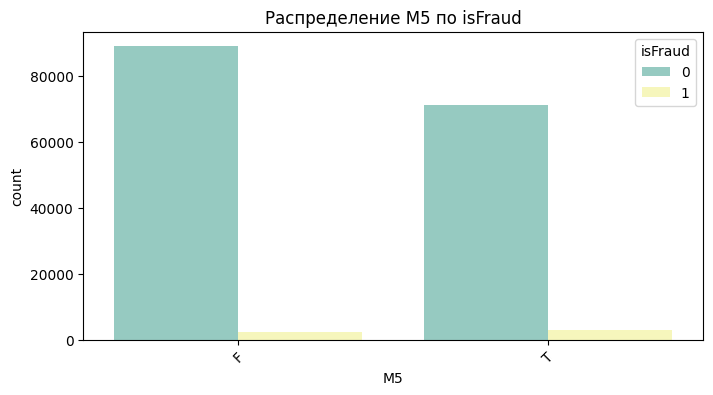


Уникальные значения для M6:
2


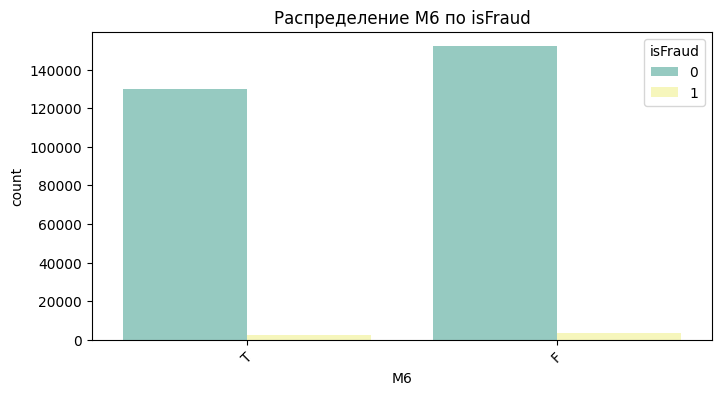


Уникальные значения для M7:
2


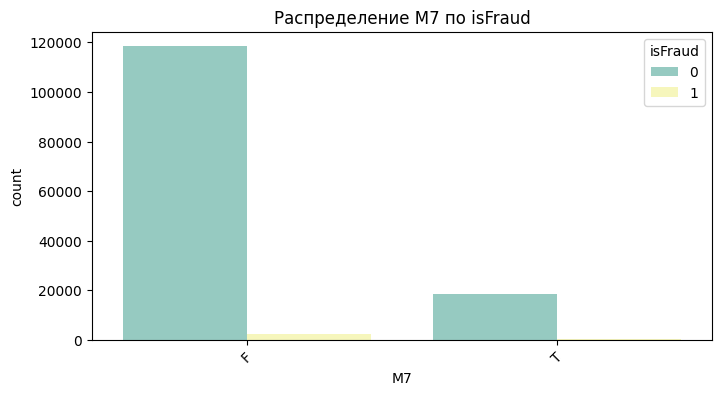


Уникальные значения для M8:
2


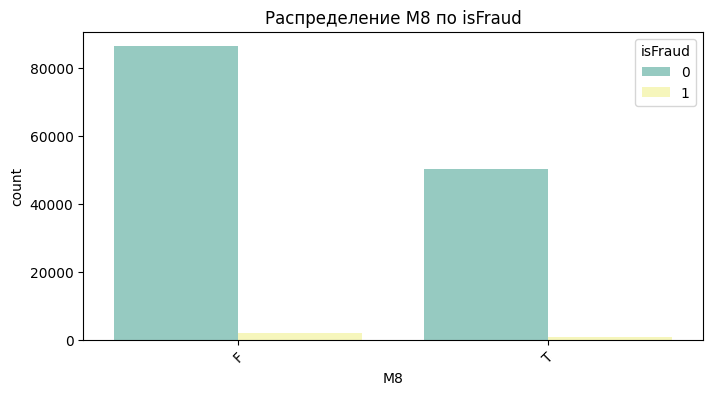


Уникальные значения для M9:
2


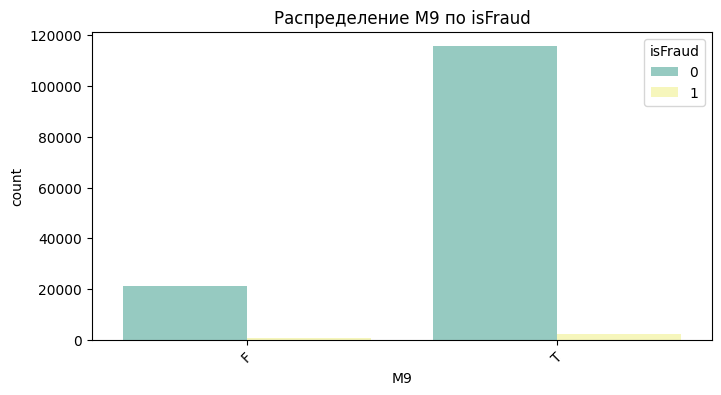


Уникальные значения для id_12:
2


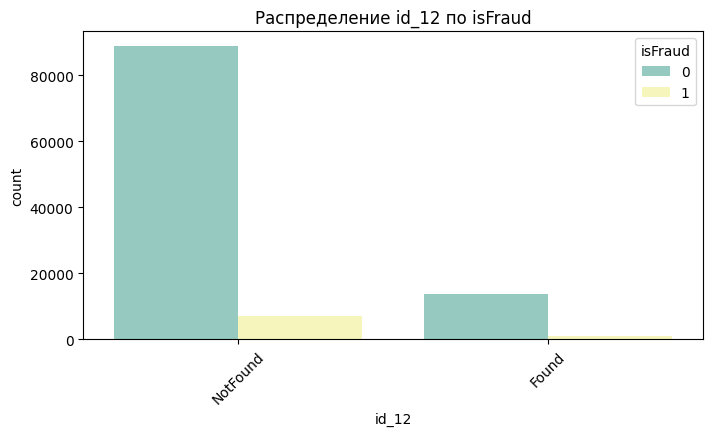


Уникальные значения для id_15:
3


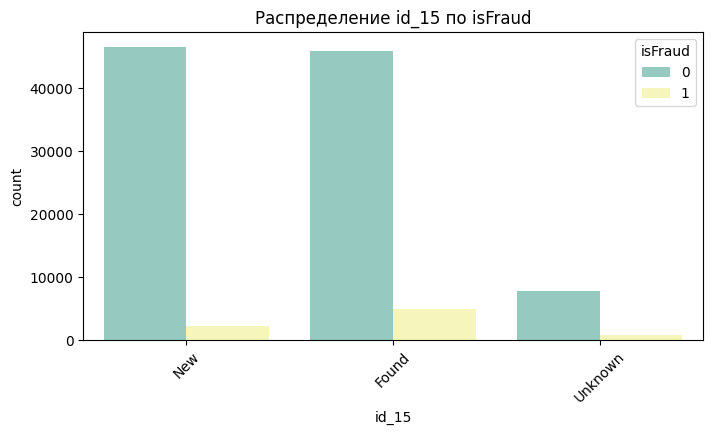


Уникальные значения для id_16:
2


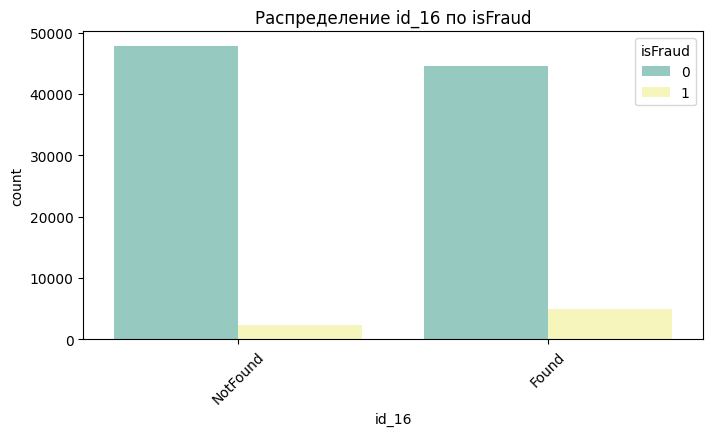


Уникальные значения для id_23:
3


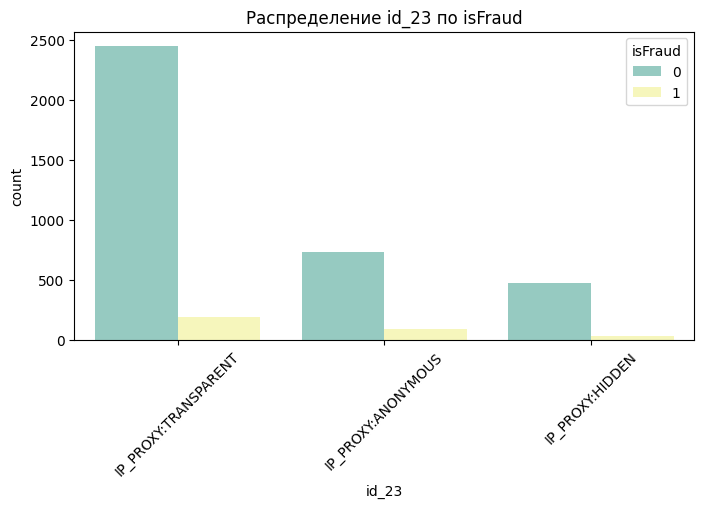


Уникальные значения для id_27:
2


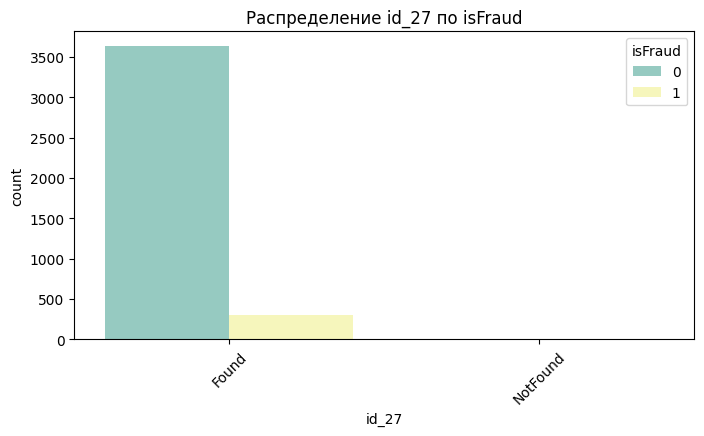


Уникальные значения для id_28:
2


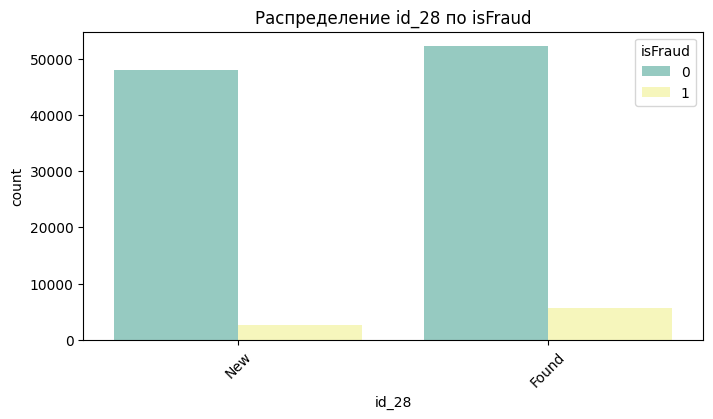


Уникальные значения для id_29:
2


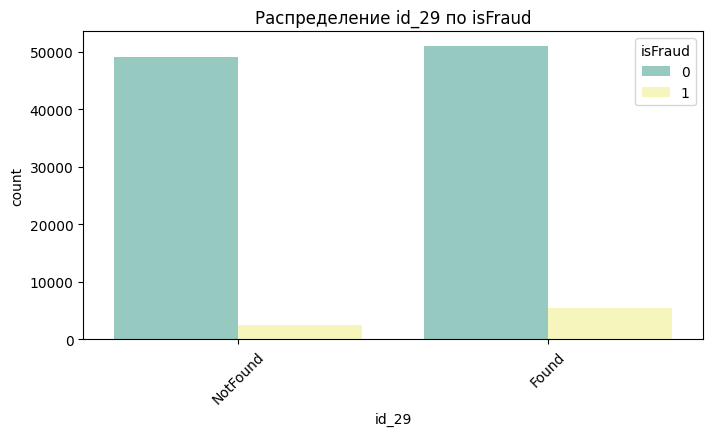


Уникальные значения для id_30:
71

Уникальные значения для id_31:
110

Уникальные значения для id_33:
183

Уникальные значения для id_34:
4


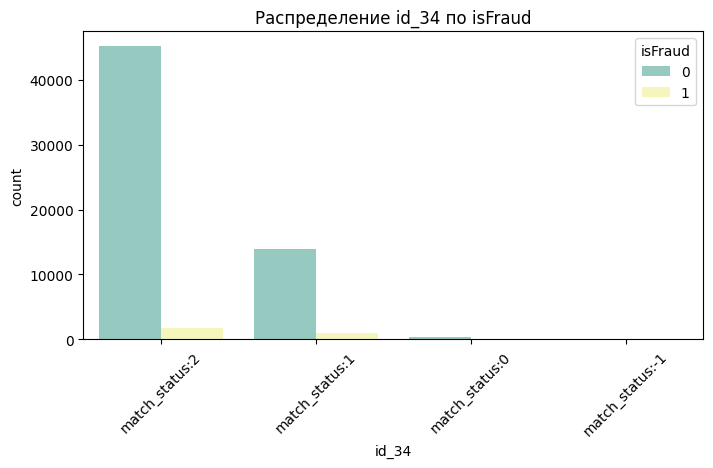


Уникальные значения для id_35:
2


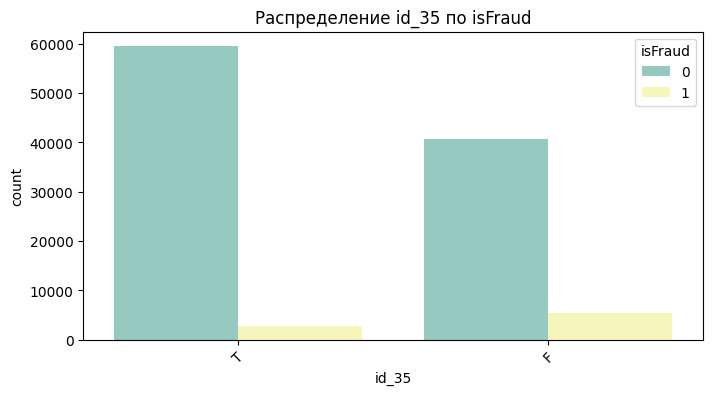


Уникальные значения для id_36:
2


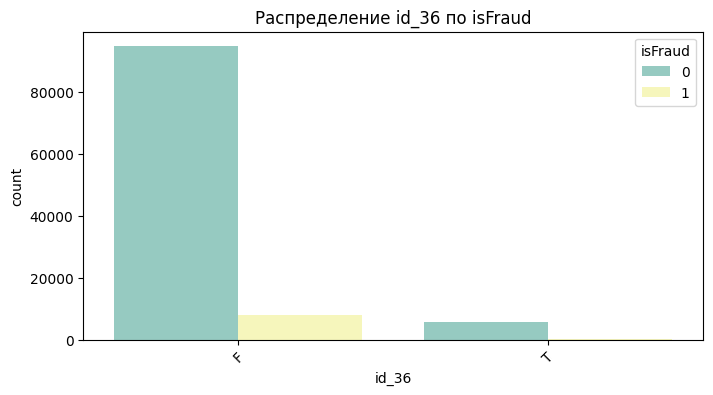


Уникальные значения для id_37:
2


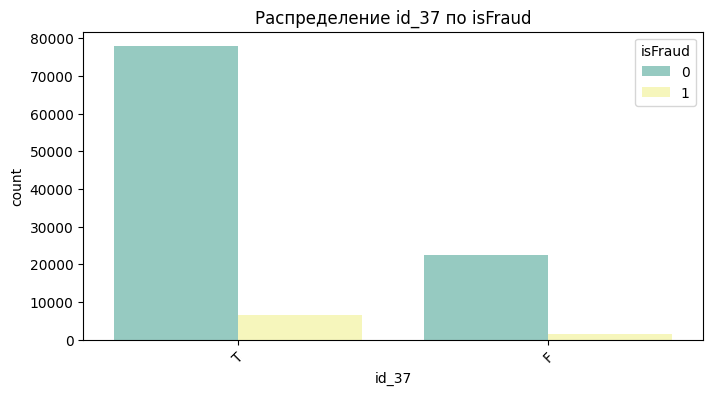


Уникальные значения для id_38:
2


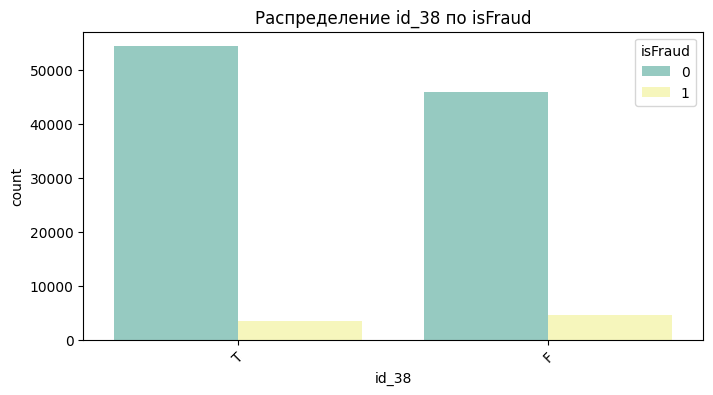


Уникальные значения для DeviceType:
2


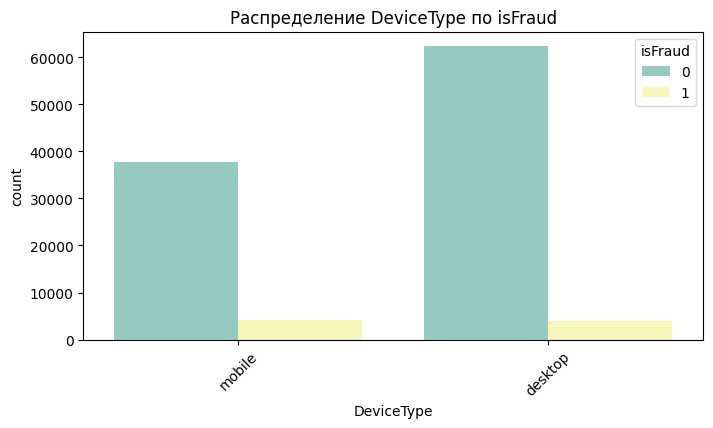


Уникальные значения для DeviceInfo:
1551


In [16]:
# связь кат. признака с целевой переменной
for col in categorical_columns:
    print(f"\nУникальные значения для {col}:")
    print(df_train[col].nunique())

    '''
    Построим графики для признаков, у которых <=10
    уникальных значений
    '''
    if df_train[col].nunique() <= 10:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, data=df_train, palette='Set3', hue='isFraud')
        plt.title(f'Распределение {col} по isFraud')
        plt.xticks(rotation=45)
        plt.show()

In [17]:
print("Описательная статистика категориальных признаков:")
df_train[categorical_columns].describe()

Описательная статистика категориальных признаков:


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
count,417559,416730,416733,352649,103820,194116,194116,194116,215646,165564,...,62096,107961,57819,62168,108273,108273,108273,108273,108124,91959
unique,5,4,4,59,60,2,2,2,3,2,...,71,110,183,4,2,2,2,2,2,1551
top,W,visa,debit,gmail.com,gmail.com,T,T,T,M0,F,...,Windows 10,chrome 63.0,1920x1080,match_status:2,T,F,T,T,desktop,Windows
freq,301297,272753,306554,160974,43010,194098,173868,152682,136257,91343,...,16078,21821,13466,46931,62152,102536,84398,57779,66324,36841


> По графикам видно, что фродовских транзакций гараздо меньше вне зависимости от значения категориального признака. Также, есть признаки, в которых много уникальных значений. В дальнейшем с такими признаками стоит поработать отдельно.

In [18]:
# числовые признаки
numerical_columns = list(df_train.select_dtypes(include=['int', 'float']).columns)

In [19]:
print("Описательная статистика числовых признаков:")
df_train[numerical_columns].describe()

Описательная статистика числовых признаков:


,TransactionAmt,D8,D9,V126,V127,V128,V129,V130,V131,V132,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_11
count,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,...,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000,417559.000000
mean,134.666550,19.559401,-0.788503,39.691315,155.851883,73.536072,8.606789,80.953400,27.693863,17.669556,...,11.419909,16.080784,13.210349,0.645891,3.083903,1.422102,3.804170,4.682749,4.095501,91.782127
std,238.153122,101.849319,0.548024,346.076385,700.441284,428.552002,125.208633,280.775696,159.563797,226.350479,...,248.493576,292.434235,257.790314,107.641762,125.912041,109.705162,118.905792,128.603714,120.820877,4.763547
min,0.251000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,89.000000
25%,42.950001,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,89.000000
50%,68.949997,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,89.000000
75%,125.000000,-1.000000,-1.000000,0.000000,98.000000,0.000000,0.000000,54.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,96.190002
max,31937.390625,1707.791626,0.958333,65297.171875,65297.171875,65297.171875,55125.000000,55125.000000,55125.000000,63874.781250,...,55125.000000,55125.000000,55125.000000,55125.000000,55125.000000,55125.000000,25000.000000,25000.000000,25000.000000,100.000000


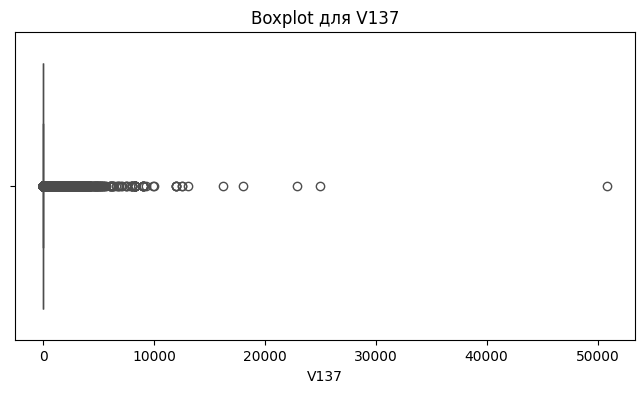

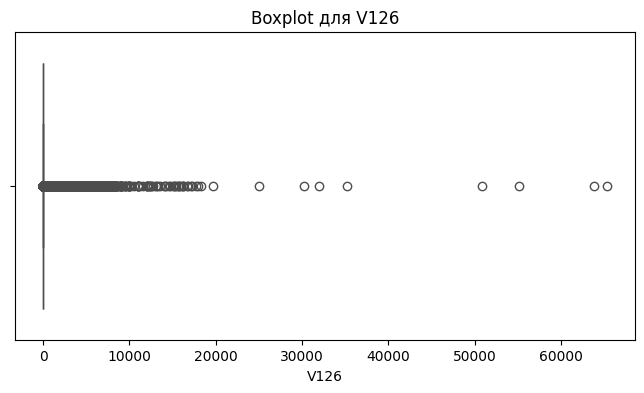

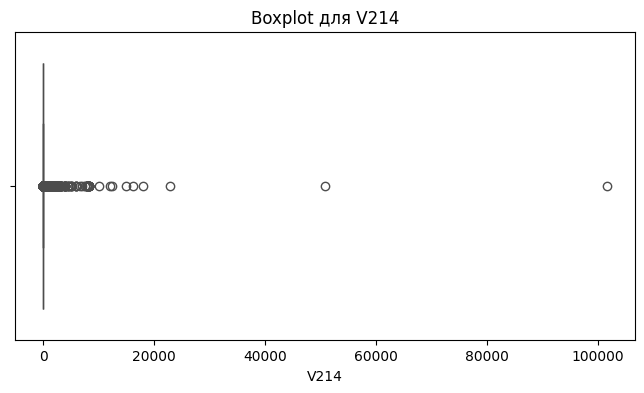

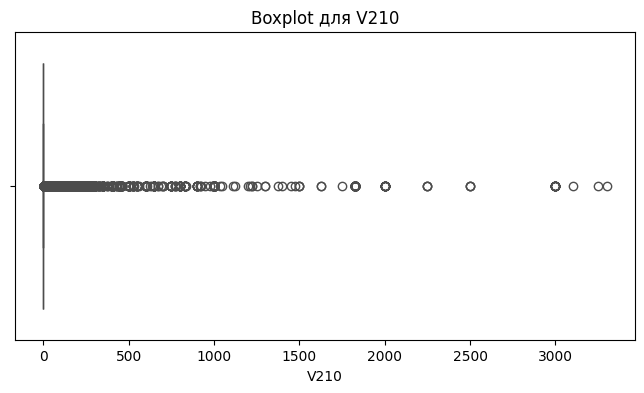

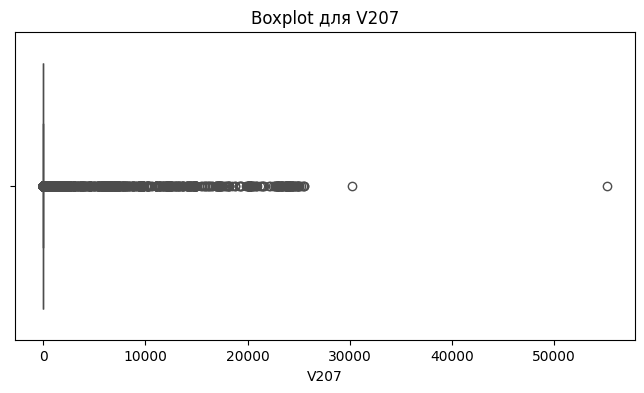

In [20]:
# посмотим на выбросы для 5-ти случайных признаков
random.seed(42)
random_numerical_columns = random.sample(numerical_columns, 5)

for col in random_numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[col], color='orange')
    plt.title(f'Boxplot для {col}')
    plt.show()

>Большенство значений очень маленькие, поэтому вместо ящика видим "линию", также наблюдается большое число выбросов. Выбросы удалять не будем, т.к. есть вероятность что это не ошибка данных, а реальные значения.

### 1.2. Анализ целево переменной

In [21]:
print('Распределение целевой переменной:')
print(df_train['isFraud'].value_counts(normalize=True))

Распределение целевой переменной:
isFraud
0    0.964745
1    0.035255
Name: proportion, dtype: float64


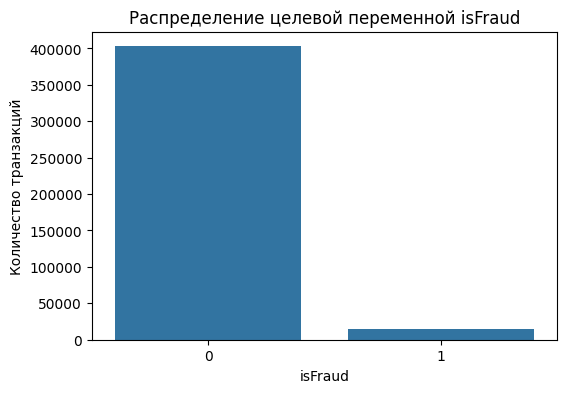

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df_train)
plt.title('Распределение целевой переменной isFraud')
plt.xlabel('isFraud')
plt.ylabel('Количество транзакций')
plt.show()

> Сразу видим сильный дисбаланс классов, это ожидаемо и нормально, но в дальнейшем надо это учесть. 96% от всех транзакйи - **не фрод**.

### 1.3. Анализ попарной взаимосвязи признаков, а также связи признаков и целевой переменной

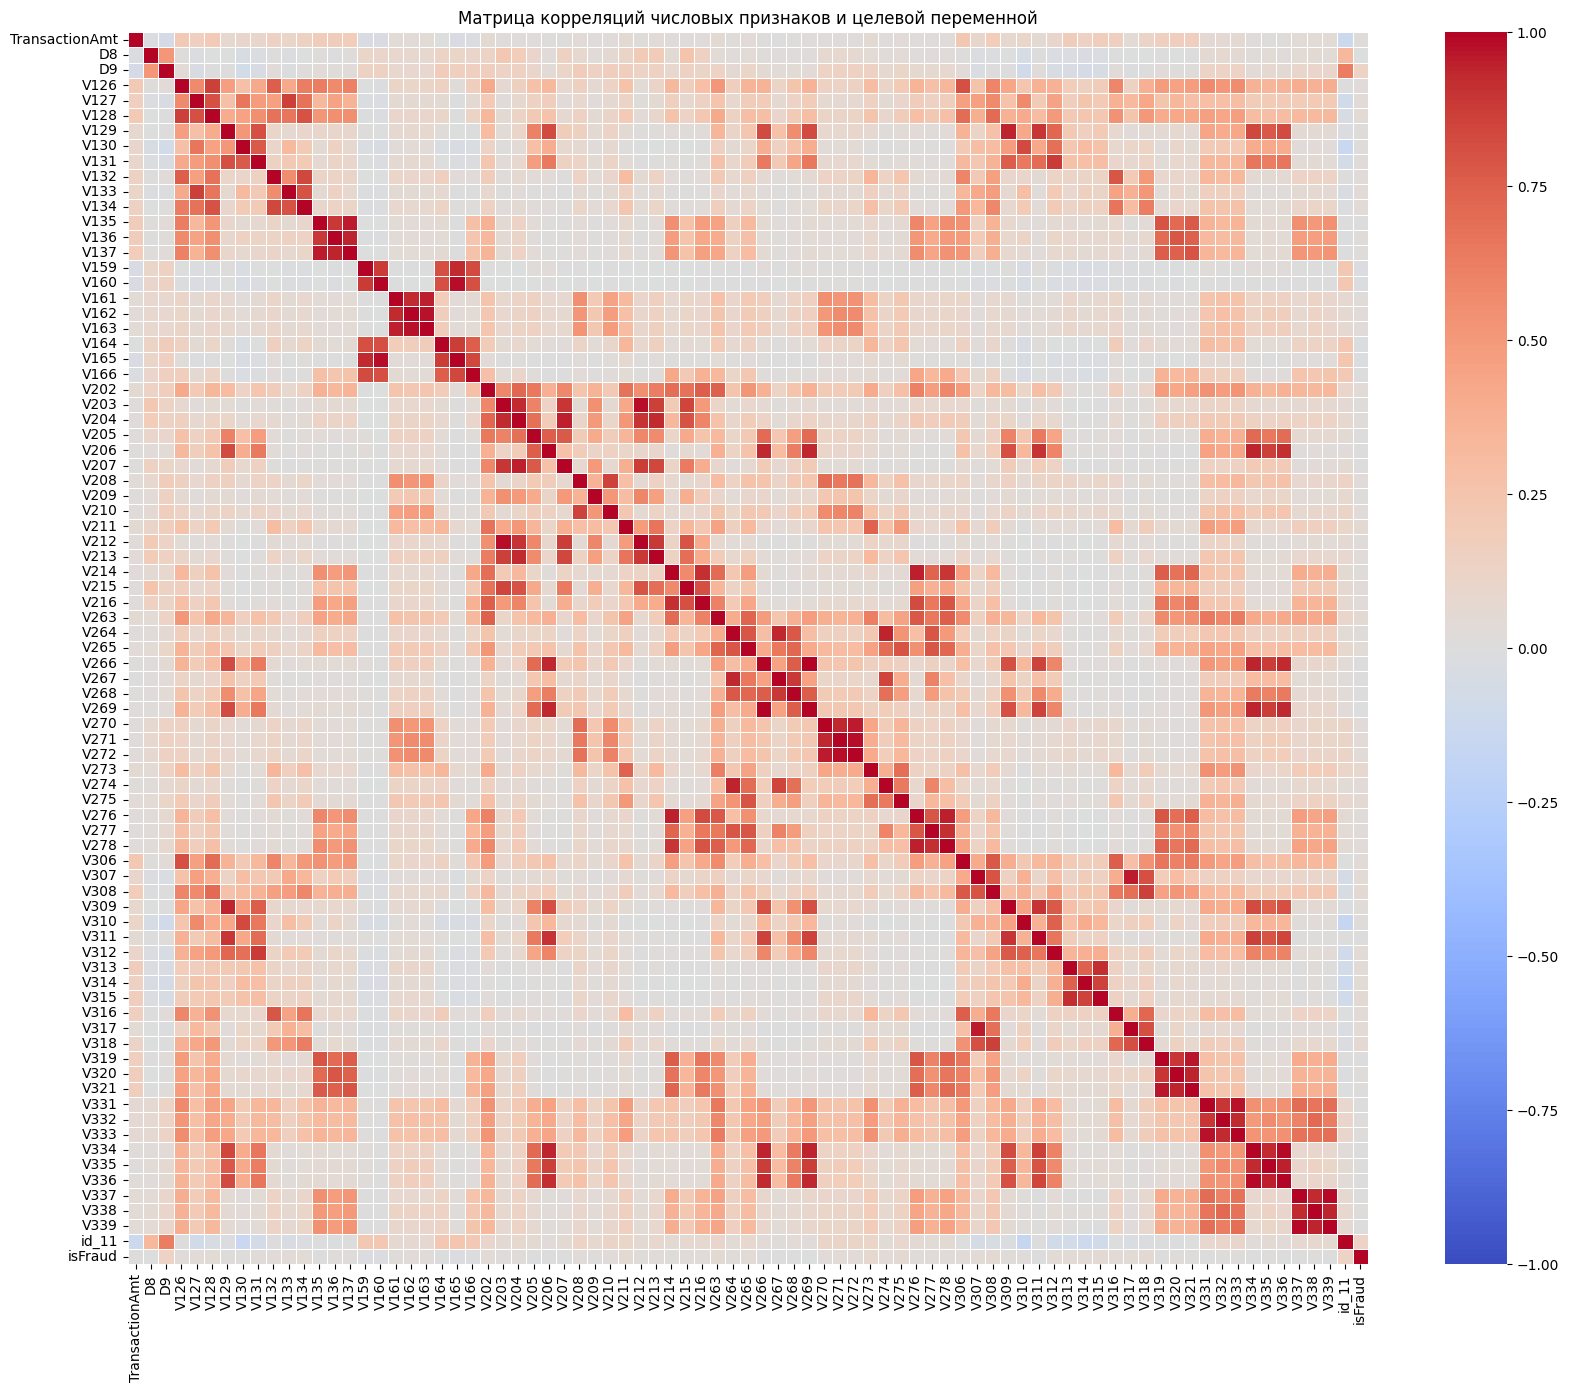

In [23]:
columns_for_corr = numerical_columns + ['isFraud']
corr_matrix = df_train[columns_for_corr].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляций числовых признаков и целевой переменной')
plt.show()

In [24]:
corr_with_target = corr_matrix['isFraud'].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной (isFraud):")
print(corr_with_target)

Корреляция признаков с целевой переменной (isFraud):
isFraud    1.000000
D9         0.126761
id_11      0.126280
V273       0.070597
V308       0.061323
             ...   
V166      -0.010258
V164      -0.014450
V165      -0.021350
V160      -0.022338
V159      -0.022747
Name: isFraud, Length: 81, dtype: float64


>По матрице корреляций видно, что числовые признаки слабо коррелируют с целевой переменной, но есть признаки, которые сильно коррелируют между собой. Удалять один из коррелирующих признаков может быть опасно, т.к. по отдельности они могут и не коррелировать между собой, а вот в совокупности давать обоснованный вклад в значение целевой переменной. Поэтому, пока не будем удалять признаки.

### 1.4. Обработка данных

### Пропуски



In [25]:
missing_counts = df_train.isna().sum()
missing_percent = (missing_counts / len(df_train)) * 100
missing_percent_sorted = missing_percent.sort_values(ascending=False)

print("Процент пропусков в каждом столбце:")
print(missing_percent_sorted)

Процент пропусков в каждом столбце:
id_27    99.053068
id_23    99.053068
id_33    86.153095
id_30    85.128808
id_34    85.111565
           ...    
V97       0.000000
V96       0.000000
V95       0.000000
V94       0.000000
V164      0.000000
Length: 432, dtype: float64


> У нас много различных признаков, в некоторых процент пропусков очень большой (85%-99%). Заменим пропуски в категориальных столбцах на **Unknown**, в числовых на пустую строку (как в примере выше). Удалять с пропусками не будем, иначе потеряем много информаци.

In [26]:
df_train[categorical_columns] = df_train[categorical_columns].fillna('Unknown')
df_train[numerical_columns] = df_train[numerical_columns].fillna('')

df_test[categorical_columns] = df_test[categorical_columns].fillna('Unknown')
df_test[numerical_columns] = df_test[numerical_columns].fillna('')

### Дубли

In [27]:
num_duplicates_train = df_train.duplicated().sum()
num_duplicates_test = df_test.duplicated().sum()
print(f"Количество дубликатов в тренировочных данных: {num_duplicates_train}")
print(f"Количество дубликатов в тестовых данных: {num_duplicates_test}")

Количество дубликатов в тренировочных данных: 270
Количество дубликатов в тестовых данных: 81


In [28]:
# удаление дубликатов
df_train = df_train.drop_duplicates().reset_index(drop=True)
#df_test = df_test.drop_duplicates().reset_index(drop=True)

### Категориальные признаки

> Хоть некоторые модели и умеют работать с категориальными признаками, для удобства закодируем их с помощью OHE. А также, стандартизируем данные, т.к. они имеют разный масштаб, что может влиять на результат модели:

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),  # стандартизируем числовые признаки
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)  # OHE для категориальных
        ])

❗ Работа с признаками осуществляется в Бонусном задание ❗

# **Задание 2 (3 балла)**

Обучите несколько ML-моделей для решения поставленной задачи.
Оцените их качество двумя способами:

1) на кросс-валидации

2) на лидерборде

Подберите число фолдов на кросс-валидации так, чтобы метрики, которые вы видите, были максимально близки на кросс-валидации и на лидерборде.

По результатам экспериментов постройте таблицу:
* в каждой строке таблицы - результаты одной модели
* по столбцам: качество на кросс-валидации, качество на лидерборде, модель с гиперпараметрами
Полученную таблицу вставьте картинкой прямо в ноутбук после ячеек с кодом. Сделайте текстовые выводы.

In [30]:
X = df_train.drop(columns=['isFraud'])
y = df_train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

> Обучим лог. регрессию, CatBoost и LightGBM с параметрами по умолчанию. Для лучшей модели подберем параметры и попробуем улучшить качество.

### Логистическая регрессия

In [31]:
logreg_results_loaded = load('/content/logreg_results.joblib')

logreg_pipeline = logreg_results_loaded['pipeline']
logreg_cv_scores = logreg_results_loaded['cv_scores']
logreg_cv_mean = logreg_results_loaded['cv_mean']

In [32]:
# logreg_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(random_state=42))
# ])

# logreg_cv_scores = cross_val_score(logreg_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
# logreg_cv_mean = logreg_cv_scores.mean()

# logreg_pipeline.fit(X_train, y_train)

In [33]:
# logreg_results = {
#     'pipeline': logreg_pipeline,
#     'cv_scores': logreg_cv_scores,
#     'cv_mean': logreg_cv_mean
# }

# dump(logreg_results, 'logreg_results.joblib')

In [34]:
logreg_val_preds = logreg_pipeline.predict_proba(X_val)[:, 1]
logreg_val_score = roc_auc_score(y_val, logreg_val_preds)

print(f'Logistic Regression:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {logreg_cv_mean:.4f}')
print(f'ROC-AUC на валидационной выборке: {logreg_val_score:.4f}')

Logistic Regression:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8323
ROC-AUC на валидационной выборке: 0.8331


In [35]:
# predictions = logreg_pipeline.predict_proba(df_test)
# sub_logreg = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 1]})
# sub_logreg.to_csv('submission_logreg.csv', index=False)

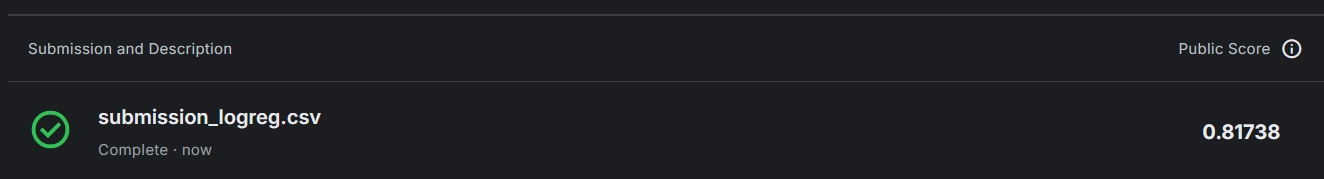

### CatBoost

In [36]:
catboost_results_loaded = load('/content/catboost_results.joblib')

catboost_pipeline = catboost_results_loaded['pipeline']
catboost_cv_scores = catboost_results_loaded['cv_scores']
catboost_cv_mean = catboost_results_loaded['cv_mean']

In [37]:
# start_train_time = time.time()

# catboost_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(random_state=42, verbose=100))
# ])

# catboost_cv_scores = cross_val_score(catboost_pipeline, X_train, y_train, cv=3, scoring='roc_auc')
# catboost_cv_mean = catboost_cv_scores.mean()

# catboost_pipeline.fit(X_train, y_train)

# end_train_time = time.time()
# train_time = end_train_time - start_train_time

In [38]:
# catboost_results = {
#     'pipeline': catboost_pipeline,
#     'cv_scores': catboost_cv_scores,
#     'cv_mean': catboost_cv_mean
# }

# dump(catboost_results, 'catboost_results.joblib')

In [39]:
start_val_time = time.time()
catboost_val_preds = catboost_pipeline.predict_proba(X_val)[:, 1]
end_val_time = time.time()
val_time = end_val_time - start_val_time

catboost_val_score = roc_auc_score(y_val, catboost_val_preds)

In [40]:
start_inference_time = time.time()

predictions = catboost_pipeline.predict_proba(df_test)

end_inference_time = time.time()
inference_time = end_inference_time - start_inference_time

In [41]:
# sub_catboost = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 1]})
# sub_catboost.to_csv('submission_catboost.csv', index=False)

In [42]:
print(f'CatBoost:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {catboost_cv_mean:.4f}')
print(f'ROC-AUC на валидационной выборке: {catboost_val_score:.4f}')

CatBoost:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8901
ROC-AUC на валидационной выборке: 0.8977


In [43]:
# print(f'Время обучения: {train_time:.2f} секунд')
# print(f'Время инференса на валидационных данных: {val_time:.2f} секунд')
# print(f'Время инференса на тестовых данных: {inference_time:.2f} секунд')

### Замер времени
* Время обучения: 647.89 секунд  
* Время инференса на валидационных данных: 1.96 секунд  
* Время инференса на тестовых данных: 4.30 секунд  

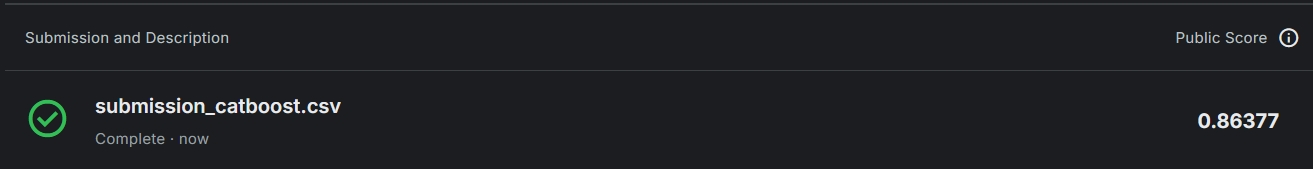

### LightGBM

In [44]:
lgbm_results_loaded = load('/content/lgbm_results.joblib')

lgbm_pipeline = lgbm_results_loaded['pipeline']
lgbm_cv_scores = lgbm_results_loaded['cv_scores']
lgbm_cv_mean = lgbm_results_loaded['cv_mean']

In [45]:
# lgbm_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LGBMClassifier(random_state=42, verbose=0))
# ])

# lgbm_cv_scores = cross_val_score(lgbm_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
# lgbm_cv_mean = lgbm_cv_scores.mean()

# lgbm_pipeline.fit(X_train, y_train)

In [46]:
# lgbm_results = {
#     'pipeline': lgbm_pipeline,
#     'cv_scores': lgbm_cv_scores,
#     'cv_mean': lgbm_cv_mean
# }

# dump(lgbm_results, 'lgbm_results.joblib')

In [47]:
lgbm_val_preds = lgbm_pipeline.predict_proba(X_val)[:, 1]
lgbm_val_score = roc_auc_score(y_val, lgbm_val_preds)

print(f'LightGBM:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {lgbm_cv_mean:.4f}')
print(f'ROC-AUC на валидационной выборке: {lgbm_val_score:.4f}')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8907
ROC-AUC на валидационной выборке: 0.8926


In [48]:
# predictions = lgbm_pipeline.predict_proba(df_test)
# sub_lgbm = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 1]})
# sub_lgbm.to_csv('submission_lgbm.csv', index=False)

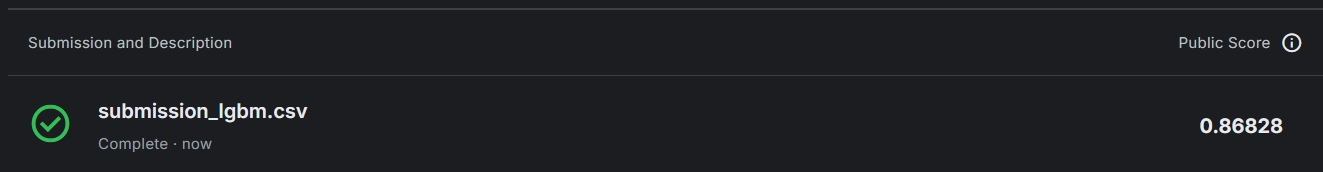

### Stacking

In [49]:
catboost_train_preds = catboost_pipeline.predict_proba(X_train)[:, 1]
lgbm_train_preds = lgbm_pipeline.predict_proba(X_train)[:, 1]

stacked_train_preds = np.column_stack((catboost_train_preds, lgbm_train_preds))

meta_model = LGBMClassifier(verbose=0, random_state=42)
meta_model.fit(stacked_train_preds, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBMClassifier(random_state=42, verbose=0)

In [50]:
catboost_val_preds = catboost_pipeline.predict_proba(X_val)[:, 1]
lgbm_val_preds = lgbm_pipeline.predict_proba(X_val)[:, 1]

stacked_val_preds = np.column_stack((catboost_val_preds, lgbm_val_preds))

stacked_val_preds_meta = meta_model.predict_proba(stacked_val_preds)[:, 1]

stacked_roc_auc = roc_auc_score(y_val, stacked_val_preds_meta)
print(f'ROC-AUC стекинга: {stacked_roc_auc}')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ROC-AUC стекинга: 0.8984089934467243


In [51]:
# catboost_test_preds = catboost_pipeline.predict_proba(df_test)[:, 1]
# lgbm_test_preds = lgbm_pipeline.predict_proba(df_test)[:, 1]

# stacked_test_preds = np.column_stack((catboost_test_preds, lgbm_test_preds))
# test_predictions = meta_model.predict_proba(stacked_test_preds)[:, 1]
# sub_meta_model = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': test_predictions})

# sub_meta_model.to_csv('submission_meta_model.csv', index=False)

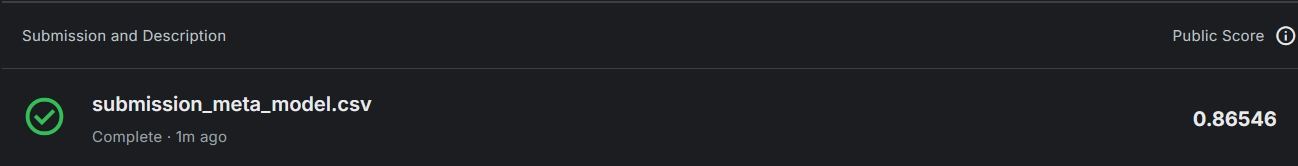

### Итоговый результат:

In [52]:
results = [
    {'Model': 'Logistic Regression', 'CV ROC-AUC': logreg_cv_mean, 'Leaderboard ROC-AUC': 0.81738, 'Hyperparameters': 'default'},
    {'Model': 'CatBoost', 'CV ROC-AUC': catboost_cv_mean, 'Leaderboard ROC-AUC': 0.86377, 'Hyperparameters': 'default'},
    {'Model': 'LightGBM', 'CV ROC-AUC': lgbm_cv_mean, 'Leaderboard ROC-AUC': 0.8682, 'Hyperparameters': 'default'},
    {'Model': 'Stacking', 'CV ROC-AUC': stacked_roc_auc, 'Leaderboard ROC-AUC': 0.86546, 'Hyperparameters': 'default'}
]

results_df = pd.DataFrame(results)

In [53]:
results_df

,Model,CV ROC-AUC,Leaderboard ROC-AUC,Hyperparameters
0,Logistic Regression,0.832284,0.81738,default
1,CatBoost,0.890103,0.86377,default
2,LightGBM,0.890675,0.86820,default
3,Stacking,0.898409,0.86546,default


>Лучшее значение метрике на Leaderboard у LightGBM (ROC-AUC ~ 0.87), однако лучшее значение на валидационных данных удалось достичь с приминением стэкинга.
Подобрать гиперпараметры не удалось, т.к. не хватает ресурсов, попробую сделать это в облаке.

# **Задание 3 (2 балла)**

Попробуйте подойти к задаче как к поиску аномалий.

1) Поищите аномалии (фрод) различными рассмотренными в курсе методами и сделайте прогноз на тестовых данных.

Результатом также будет таблица:
* по строкам - методы поиска аномалий
* по столбцам - качество вашего решения на leaderboard

2) Попробуйте встроить поиск аномалий и их удаление в ML-пайплайн: найдите аномалии и что-нибудь с ними сделайте до обучения моделей (можно удалить их, а можно использовать в качестве дополнительных признаков - попробуйте разные стратегии). Результат проверьте на кросс-валидации и на лидерборде, сделайте выводы.

### 3.1. Поиск аномалий различными методами

### Isolation Forest

In [54]:
iso_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(contamination=0.01, random_state=42))
])

iso_forest_pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TransactionAmt', 'D8', 'D9',
                                                   'V126', 'V127', 'V128',
                                                   'V129', 'V130', 'V131',
                                                   'V132', 'V133', 'V134',
                                                   'V135', 'V136', 'V137',
                                                   'V159', 'V160', 'V161',
                                                   'V162', 'V163', 'V164',
                                                   'V165', 'V166', 'V202',
                                                   'V203', 'V204', 'V205',
                                                   'V206', 'V207', 'V208', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ProductCD', 'card4',
                                                   'card6', 'P_emaildomain',
                                                   'R_emaildomain', 'M1', 'M2',
                                                   'M3', 'M4', 'M5', 'M6', 'M7',
                                                   'M8', 'M9', 'id_12', 'id_15',
                                                   'id_16', 'id_23', 'id_27',
                                                   'id_28', 'id_29', 'id_30',
                                                   'id_31', 'id_33', 'id_34',
                                                   'id_35', 'id_36', 'id_37',
                                                   'id_38', 'DeviceType', ...])])),
                ('classifier',
                 IsolationForest(contamination=0.01, random_state=42))])

In [55]:
iso_val_preds = -iso_forest_pipeline.decision_function(X_val)
iso_val_probs = (iso_val_preds - iso_val_preds.min()) / (iso_val_preds.max() - iso_val_preds.min())
iso_val_score = roc_auc_score(y_val, iso_val_probs)
print(f'Isolation Forest:')
print('-' * 45)
print(f'ROC-AUC на валидационной выборке: {iso_val_score:.4f}')

Isolation Forest:
---------------------------------------------
ROC-AUC на валидационной выборке: 0.7446


In [56]:
# iso_test_preds = -iso_forest_pipeline.decision_function(df_test)
# iso_test_probs = (iso_test_preds - iso_test_preds.min()) / (iso_test_preds.max() - iso_test_preds.min())

# sub_iso_forest = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': iso_test_probs})
# sub_iso_forest.to_csv('submission_iso_forest.csv', index=False)

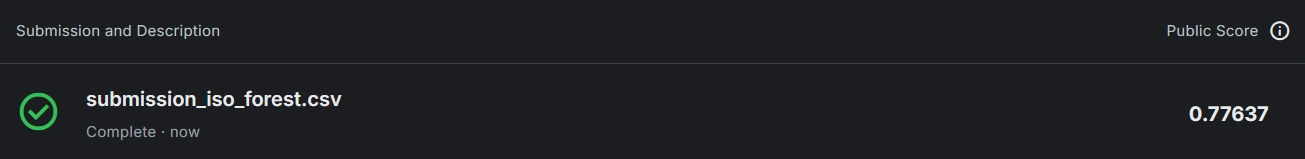

### MiniBatch K-Means

In [57]:
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('cluster', MiniBatchKMeans(n_clusters=10, random_state=42, batch_size=1000))
])

kmeans_pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TransactionAmt', 'D8', 'D9',
                                                   'V126', 'V127', 'V128',
                                                   'V129', 'V130', 'V131',
                                                   'V132', 'V133', 'V134',
                                                   'V135', 'V136', 'V137',
                                                   'V159', 'V160', 'V161',
                                                   'V162', 'V163', 'V164',
                                                   'V165', 'V166', 'V202',
                                                   'V203', 'V204', 'V205',
                                                   'V206', 'V207', 'V208', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ProductCD', 'card4',
                                                   'card6', 'P_emaildomain',
                                                   'R_emaildomain', 'M1', 'M2',
                                                   'M3', 'M4', 'M5', 'M6', 'M7',
                                                   'M8', 'M9', 'id_12', 'id_15',
                                                   'id_16', 'id_23', 'id_27',
                                                   'id_28', 'id_29', 'id_30',
                                                   'id_31', 'id_33', 'id_34',
                                                   'id_35', 'id_36', 'id_37',
                                                   'id_38', 'DeviceType', ...])])),
                ('cluster',
                 MiniBatchKMeans(batch_size=1000, n_clusters=10,
                                 random_state=42))])

In [58]:
centroids = kmeans_pipeline.named_steps['cluster'].cluster_centers_

X_val_transformed = kmeans_pipeline.named_steps['preprocessor'].transform(X_val)
val_distances = np.min(euclidean_distances(X_val_transformed, centroids), axis=1)
val_probs = (val_distances - val_distances.min()) / (val_distances.max() - val_distances.min())

kmeans_val_score = roc_auc_score(y_val, val_probs)
print(f'MiniBatch K-Means ROC-AUC на валидационной выборке: {kmeans_val_score:.4f}')

MiniBatch K-Means ROC-AUC на валидационной выборке: 0.7142


In [59]:
# X_test_transformed = kmeans_pipeline.named_steps['preprocessor'].transform(df_test)
# test_distances = np.min(euclidean_distances(X_test_transformed, centroids), axis=1)
# test_probs = (test_distances - test_distances.min()) / (test_distances.max() - test_distances.min())

# sub_kmeans = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': test_probs})
# sub_kmeans.to_csv('submission_kmeans.csv', index=False)

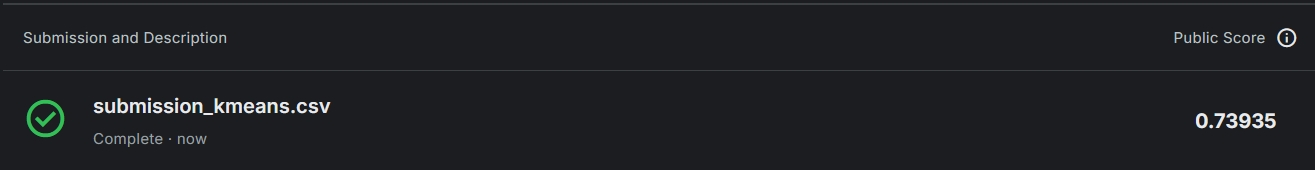

### Итоговый результат

In [60]:
results_anomalies = [
    {'Method': 'Isolation Forest', 'CV ROC-AUC': iso_val_score, 'Leaderboard ROC-AUC': 0.77637},
    {'Method': 'MiniBatch K-Means', 'CV ROC-AUC': kmeans_val_score, 'Leaderboard ROC-AUC': 0.73935}
]

results_anomalies = pd.DataFrame(results_anomalies)

In [61]:
results_anomalies

,Method,CV ROC-AUC,Leaderboard ROC-AUC
0,Isolation Forest,0.744565,0.77637
1,MiniBatch K-Means,0.714172,0.73935


> Использовали только те методы для поиска аномалий, которые удалось реализовать на данных ресурсах. Методы показали метрики хуже, чем обучения моделей, однако значение метрик методов на Leaderboard лучше, чем на валидационных данных.

### 3.2. Поиск аномалий в ML-пайплайне

1. Удаление аномалий

In [62]:
def remove_outliers_iqr(df, columns, threshold=1.5):
    """
    Функция для удаления выбросов по IQR
    """
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [63]:
X_train_clean = remove_outliers_iqr(X_train, numerical_columns)
y_train_clean = y_train.loc[X_train_clean.index]

In [64]:
catboost_results_loaded = load('/content/catboost_results_clean.joblib')

catboost_pipeline_clean = catboost_results_loaded['pipeline']
catboost_cv_scores_clean = catboost_results_loaded['cv_scores']
catboost_cv_mean_clean = catboost_results_loaded['cv_mean']

In [65]:
# catboost_pipeline_clean = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(random_state=42, verbose=100))
# ])

# catboost_cv_scores_clean = cross_val_score(catboost_pipeline_clean, X_train_clean, y_train_clean, cv=3, scoring='roc_auc')
# catboost_cv_mean_clean = catboost_cv_scores_clean.mean()

# catboost_pipeline_clean.fit(X_train_clean, y_train_clean)

In [66]:
# catboost_results = {
#     'pipeline': catboost_pipeline_clean,
#     'cv_scores': catboost_cv_scores_clean,
#     'cv_mean': catboost_cv_mean_clean
# }

# dump(catboost_results, 'catboost_results_clean.joblib')

In [67]:
catboost_val_preds_clean = catboost_pipeline_clean.predict_proba(X_val)[:, 1]
catboost_val_score_clean = roc_auc_score(y_val, catboost_val_preds_clean)

print(f'CatBoost после удаления выбросов:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {catboost_cv_mean_clean:.4f}')
print(f'ROC-AUC на валидационной выборке: {catboost_val_score_clean:.4f}')

CatBoost после удаления выбросов:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.7271
ROC-AUC на валидационной выборке: 0.7248


In [68]:
# predictions_clean = catboost_pipeline_clean.predict_proba(df_test)

# sub_catboost = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions_clean[:, 1]})
# sub_catboost.to_csv('submission_catboost_clean.csv', index=False)

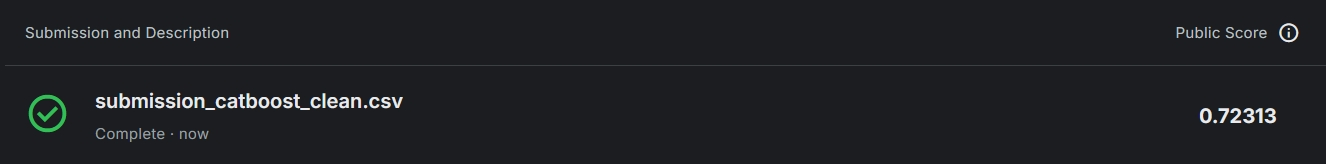

>Удаление выбросов из обучающих данных повлекло за собой сильное снижение метрики.

2. Аномалии как новые признаки

In [69]:
def add_outlier_feature(df, columns, threshold=1.5):
    """
    Добавляем бинарный признак, указывающий на выбросы.
    """
    df['is_outlier'] = 0
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), 'is_outlier'] = 1
    return df

In [70]:
X_train_outlier = add_outlier_feature(X_train, numerical_columns)
X_val_outlier = add_outlier_feature(X_val, numerical_columns)
df_test_outlier = add_outlier_feature(df_test, numerical_columns)

<ipython-input-69-a9ac115adf5d>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_outlier'] = 0


In [71]:
categorical_columns.append('is_outlier')

In [72]:
catboost_results_loaded = load('/content/catboost_results_outlier.joblib')

catboost_pipeline_outlier = catboost_results_loaded['pipeline']
catboost_cv_scores_outlier = catboost_results_loaded['cv_scores']
catboost_cv_mean_outlier = catboost_results_loaded['cv_mean']

In [73]:
# catboost_pipeline_outlier = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(random_state=42, verbose=100))
# ])

# catboost_cv_scores_outlier = cross_val_score(catboost_pipeline_outlier, X_train_outlier, y_train, cv=3, scoring='roc_auc')
# catboost_cv_mean_outlier = catboost_cv_scores_outlier.mean()

# catboost_pipeline_outlier.fit(X_train_outlier, y_train)

In [74]:
# catboost_results = {
#     'pipeline': catboost_pipeline_outlier,
#     'cv_scores': catboost_cv_scores_outlier,
#     'cv_mean': catboost_cv_mean_outlier
# }

# dump(catboost_results, 'catboost_results_outlier.joblib')

In [75]:
catboost_val_preds_outlier = catboost_pipeline_outlier.predict_proba(X_val_outlier)[:, 1]
catboost_val_score_outlier = roc_auc_score(y_val, catboost_val_preds_outlier)

In [76]:
print(f'CatBoost после удаления выбросов:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {catboost_cv_mean_outlier:.4f}')
print(f'ROC-AUC на валидационной выборке: {catboost_val_score_outlier:.4f}')

CatBoost после удаления выбросов:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8896
ROC-AUC на валидационной выборке: 0.8973


In [77]:
# predictions_outlier = catboost_pipeline_outlier.predict_proba(df_test)

# sub_catboost_outlier = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions_outlier[:, 1]})
# sub_catboost_outlier.to_csv('submission_catboost_outlier.csv', index=False)

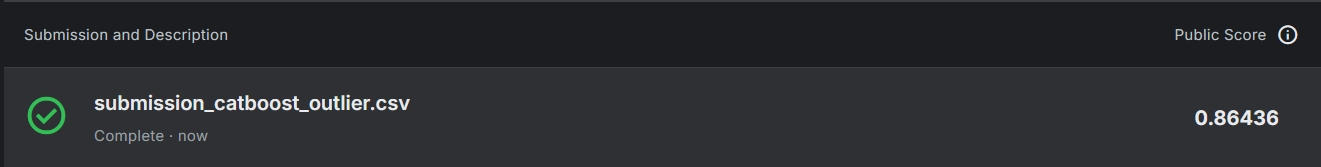

> Добавление аномалий как новые признаки улучшило значение метрики, но незначительно.

# **Задание 4 (1 балл)**

Сделайте кластеризацию различными способами. Результаты кластеризации используйте для улучшения ML-решений:

1) Номера кластеров закодируйте (OHE или target-encoding) и добавьте как новые признаки

2) При использовании DBSCAN / HDBSCAN предсказанный шум можно трактовать как найденную аномалию и также добавить ее как новый признак

Проведите различные эксперименты. Проверьте как эти подходы влияют на качество прогнозов по кросс-валидации и на лидерборде, сделайте выводы.

### 4.1. Кодируем номера кластеров и добавляем к тренировочным данным

In [78]:
X_train_processed = preprocessor.transform(X_train)

In [79]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_train_processed)

kmeans_labels = kmeans.labels_

In [80]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
kmeans_ohe = ohe.fit_transform(kmeans_labels.reshape(-1, 1))

In [81]:
kmeans_ohe_df = pd.DataFrame(kmeans_ohe, columns=['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4'])

In [82]:
X_train_reset = X_train.reset_index(drop=True)
kmeans_ohe_df_reset = kmeans_ohe_df.reset_index(drop=True)

In [83]:
print(X_train_reset.index.equals(kmeans_ohe_df_reset.index))

True


In [84]:
X_train_with_clusters = pd.concat([X_train_reset, kmeans_ohe_df_reset], axis=1)

In [85]:
# те же шаги для валидационных данных
X_val_processed = preprocessor.transform(X_val)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_val_processed)

kmeans_labels = kmeans.labels_

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
kmeans_ohe = ohe.fit_transform(kmeans_labels.reshape(-1, 1))

kmeans_ohe_df = pd.DataFrame(kmeans_ohe, columns=['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4'])

X_val_reset = X_val.reset_index(drop=True)
kmeans_ohe_df_reset = kmeans_ohe_df.reset_index(drop=True)

X_val_with_clusters = pd.concat([X_val_reset, kmeans_ohe_df_reset], axis=1)

### Обучаем модель на новых признаках

In [86]:
catboost_results_loaded = load('/content/catboost_ohe_results.joblib')

catboost_pipeline_ohe = catboost_results_loaded['pipeline']
catboost_cv_scores = catboost_results_loaded['cv_scores']
catboost_cv_mean = catboost_results_loaded['cv_mean']

In [87]:
# catboost_pipeline_ohe = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(random_state=42, verbose=100))
# ])

# catboost_cv_scores = cross_val_score(catboost_pipeline_ohe, X_train_with_clusters, y_train, cv=3, scoring='roc_auc')
# catboost_cv_mean = catboost_cv_scores.mean()

# catboost_pipeline_ohe.fit(X_train_with_clusters, y_train)

In [88]:
# catboost_ohe_results = {
#     'pipeline': catboost_pipeline_ohe,
#     'cv_scores': catboost_cv_scores,
#     'cv_mean': catboost_cv_mean
# }

# dump(catboost_ohe_results, 'catboost_ohe_results.joblib')

In [89]:
catboost_val_preds = catboost_pipeline_ohe.predict_proba(X_val_with_clusters)[:, 1]
catboost_val_score = roc_auc_score(y_val, catboost_val_preds)

print(f'CatBoost с новыми признаками:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {catboost_cv_mean:.4f}')
print(f'ROC-AUC на валидационной выборке: {catboost_val_score:.4f}')

CatBoost с новыми признаками:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8901
ROC-AUC на валидационной выборке: 0.8977


In [90]:
# predictions = catboost_pipeline_ohe.predict_proba(df_test)
# sub_catboost = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 1]})
# sub_catboost.to_csv('submission_catboost_ohe.csv', index=False)

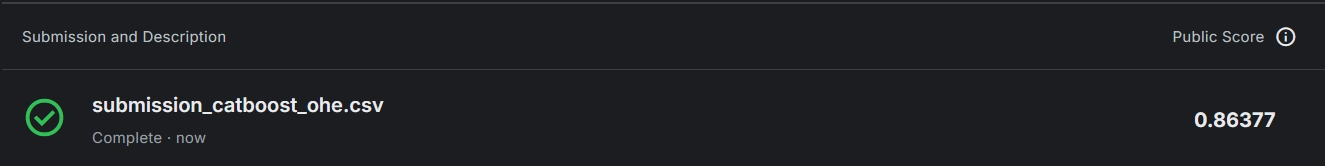

>Добавление кластеров как признаков чуть-чуть ухудшило значение метрики. На валидационных данных без изменений.

### 4.2. DBSCAN

In [91]:
dbscan_results_loaded = load('/content/dbscan_clustrs.joblib')
dbscan_clusters = dbscan_results_loaded['dbscan']

In [92]:
'''
снизим размерность, т.к. DBSCAN долго обучается
'''
pca = PCA(n_components=50, random_state=42)
X_train_reduced = pca.fit_transform(X_train_processed)

In [93]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
# dbscan_clusters = dbscan.fit_predict(X_train_reduced)

In [94]:
# dbscan_clustrs = {'dbscan': dbscan_clusters}
# dump(dbscan_clustrs, 'dbscan_clustrs.joblib')

In [95]:
X_train_dbscan = X_train.copy()
X_train_dbscan['dbscan_cluster'] = dbscan_clusters
X_train_dbscan['dbscan_noise'] = (dbscan_clusters == -1).astype(int)

---

In [96]:
dbscan_results_loaded = load('/content/dbscan_clusters_val.joblib')
dbscan_clusters_val = dbscan_results_loaded['dbscan_val']

In [97]:
# X_val_reduced = pca.transform(X_val_processed)
# dbscan_clusters_val = dbscan.fit_predict(X_val_reduced)

In [98]:
# dump({'dbscan_val': dbscan_clusters_val}, 'dbscan_clusters_val.joblib')

In [99]:
X_val_dbscan = X_val.copy()
X_val_dbscan['dbscan_cluster'] = dbscan_clusters_val
X_val_dbscan['dbscan_noise'] = (dbscan_clusters_val == -1).astype(int)

### Обучаем модель с новыми признаками после применения DBSCAN

In [100]:
catboost_results_loaded = load('/content/catboost_dbscan_results.joblib')

catboost_pipeline_dbscan = catboost_results_loaded['pipeline']
catboost_cv_scores = catboost_results_loaded['cv_scores']
catboost_cv_mean = catboost_results_loaded['cv_mean']

In [101]:
# catboost_pipeline_dbscan = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(random_state=42, verbose=100))
# ])

# catboost_cv_scores = cross_val_score(catboost_pipeline_dbscan, X_train_dbscan, y_train, cv=3, scoring='roc_auc')
# catboost_cv_mean = catboost_cv_scores.mean()

# catboost_pipeline_dbscan.fit(X_train_dbscan, y_train)

In [102]:
# catboost_dbscan_results = {
#     'pipeline': catboost_pipeline_dbscan,
#     'cv_scores': catboost_cv_scores,
#     'cv_mean': catboost_cv_mean
# }

# dump(catboost_dbscan_results, 'catboost_dbscan_results.joblib')

In [103]:
catboost_val_preds = catboost_pipeline_dbscan.predict_proba(X_val_dbscan)[:, 1]
catboost_val_score = roc_auc_score(y_val, catboost_val_preds)

print(f'CatBoost с новыми признаками:')
print('-'*45)
print(f'Средний ROC-AUC на кросс-валидации: {catboost_cv_mean:.4f}')
print(f'ROC-AUC на валидационной выборке: {catboost_val_score:.4f}')

CatBoost с новыми признаками:
---------------------------------------------
Средний ROC-AUC на кросс-валидации: 0.8901
ROC-AUC на валидационной выборке: 0.8977


In [104]:
# predictions = catboost_pipeline_dbscan.predict_proba(df_test)
# sub_catboost = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 1]})
# sub_catboost.to_csv('submission_catboost_dbscan.csv', index=False)

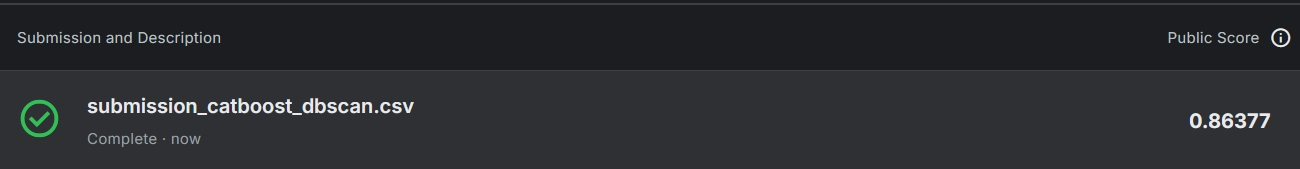

### Общий вывод

>Качество метрики на валидационных данных не изменилось с добавлением признаков. Возможно, это небольшая часть признаков никак не может повлиять на результат модели, т.к. других (изначальных) признаков очень много. Однако, на лидерборде качесво метрики снизилось, но незначительно.

## **Задание 5 (1 балл)**

Примените какой-нибудь (один любой) AutoML фреймворк для решения поставленной задачи.

Отправьте AutoML-прогноз на kaggle и посмотрите на качество модели. Сделайте текстовые выводы.

> Выбрала AutoML фреймворк (*H2O AutoML*) [отсюда](https://proglib.io/p/auto-ml)

❗ Код ниже закомментирован для экономия времени загрузки блокнота ❗

In [105]:
!pip install h2o

In [106]:
import h2o
from h2o.automl import H2OAutoML

In [107]:
# h2o.init()

In [108]:
# train = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
# val = h2o.H2OFrame(pd.concat([X_val, y_val], axis=1))
# test = h2o.H2OFrame(df_test)

In [109]:
# x = train.columns
# y = "isFraud"
# x.remove(y)

# train[y] = train[y].asfactor()
# val[y] = val[y].asfactor()

In [110]:
# aml = H2OAutoML(max_models=20, seed=42, max_runtime_secs=300)
# aml.train(x=x, y=y, training_frame=train, validation_frame=val)

In [111]:
# preds = aml.leader.predict(test)
# preds_df = preds.as_data_frame()

# test_df = test.as_data_frame()
# test_df['isFraud'] = preds_df['p1']

# sub_h2o = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': test_df['isFraud']})
# sub_h2o.to_csv('submission_h2o.csv', index=False)

In [112]:
# h2o.cluster().shutdown()

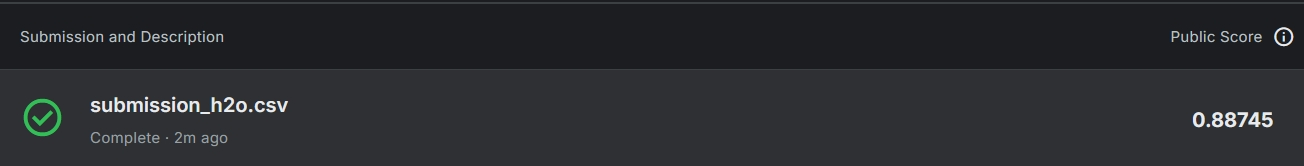

> AutoML фреймворк (H2O AutoML) обучил 20 различных моделей, лучшая - XGBoost. Благодаря примению фреймворка удалось достичь лучшее из всех значений на лидерборде.

# **Задание 6 (1 балл)**

Весь курс мы работали в Google Colab. Но всегда должны быть запасные варианты, где Вы будете обучать модели.

Среди вариантов есть:
* ваша локальная машина
* kaggle notebooks
* yandex cloud
и другие.

Кроме привычного Google Colab выберите из списка выше один любой альтернативный вариант и проведите эксперимент:

* Прогоните ваш лучший по качеству по результатам заданий 2-4 ML-пайплайн заново в Google Colab и с помощью библиотек (например, при помощи библиотеки time) замерьте время обучения и отдельно время инференса на тестовых данных

* Прогоните этот пайплайн на выбранном альтернативном сервисе/локальной машине и также замерьте время обучения и инференса.

Текстом напишите выводы: опишите, какое альтернативное место для обучения моделей Вы использовали? Прикрепите прямо в ноутбук скриншот с экраном кода в альтернативном сервисе/на локальной машине. Также в виде таблицы приведите сравнение времени обучения и инференса в колабе и в альтернативном месте. Сделайте выводы.

> Лучшее значение на лидерборде показал CatBoost (если не считать AutoML), замерим время обучения в Colab и kaggle notebooks:

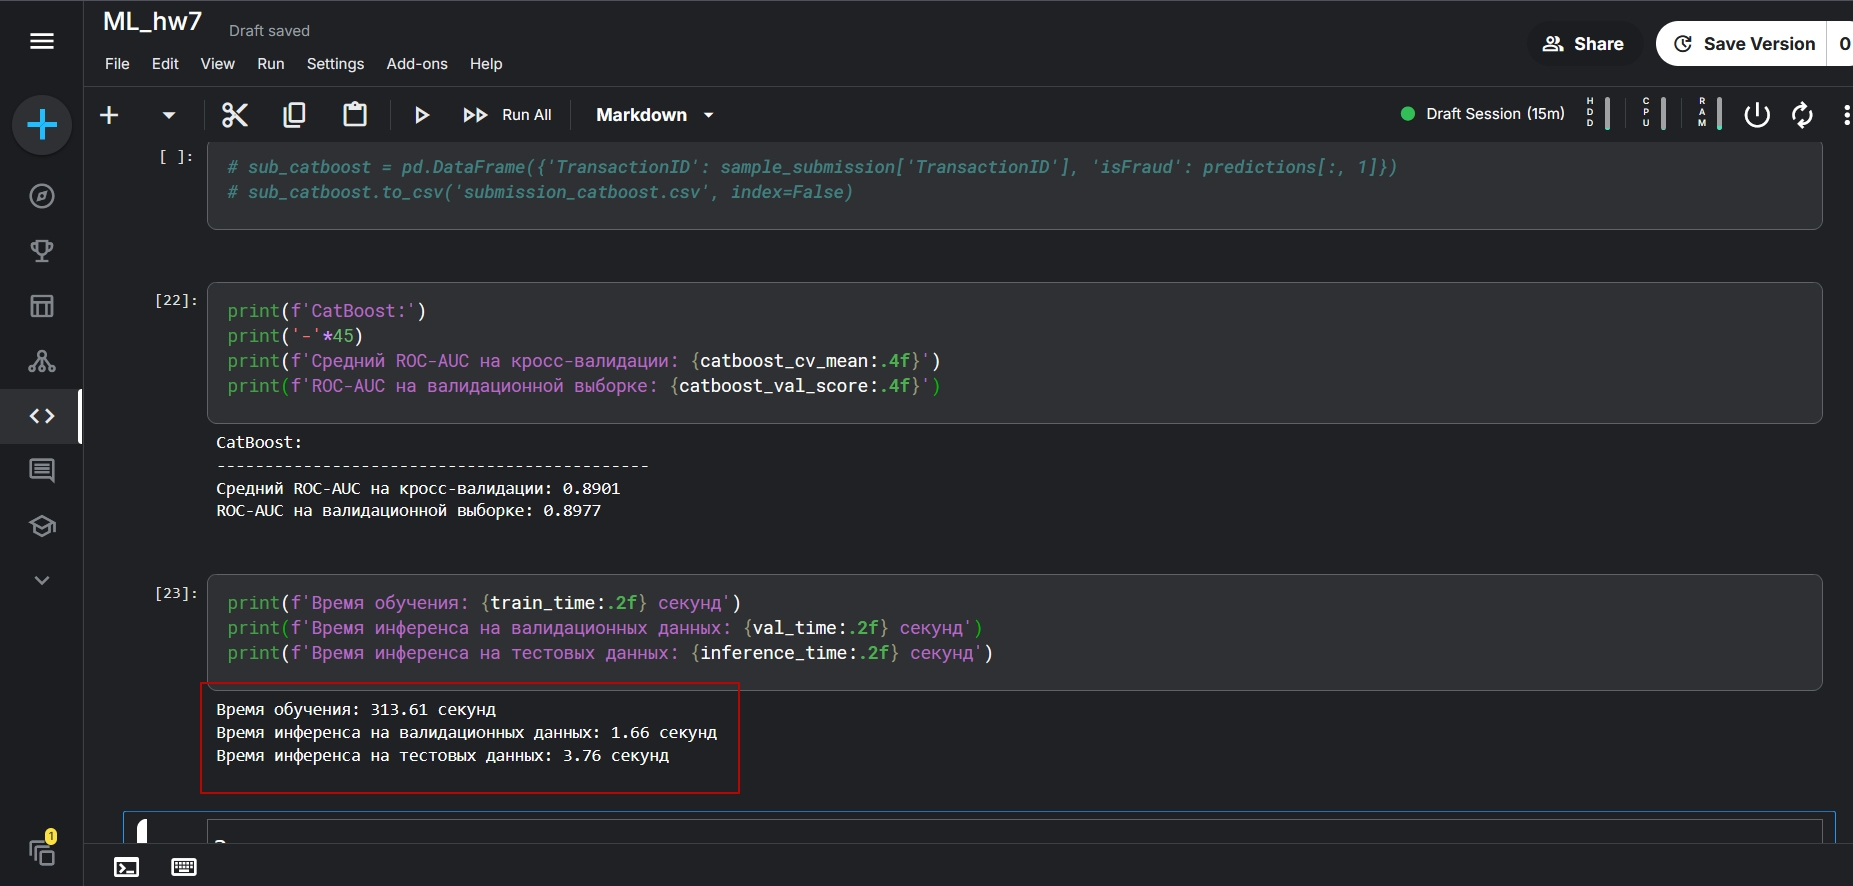

In [113]:
results_time = [
    {'Notebooks': 'Google Colab', 'train_time': 647.89, 'val_time': 1.96, 'inference_time': 4.30},
    {'Notebooks': 'Kaggle notebooks', 'train_time': 313.61, 'val_time': 1.66, 'inference_time': 3.76}
]

results_time = pd.DataFrame(results_time)

In [114]:
results_time

,Notebooks,train_time,val_time,inference_time
0,Google Colab,647.89,1.96,4.30
1,Kaggle notebooks,313.61,1.66,3.76


### Вывод

> CatBoost обучился в Kaggle notebooks в 2 раза быстрее, чем в Google Colab (314 сек. против 648 сек.). Инференс на тестовых данных отработал почти на 1 сек. быстрее.

# **Бонус: за Kaggle и стремление к хорошим скорам (2 балла)**

В этом домашнем задании Ваша цель - не просто выполнить шаги выше, но и построить максимально хорошую по качеству модель.

**К 10 вы можете получить до двух дополнительных баллов:**

* За попадание в топ-20% на private leaderboard — +1 дополнительный балл к оценке
* За попадание в топ-5 мест на private leaderboard — + еще один дополнительный балл к оценке (то есть суммарно 2 дополнительных балла)

**ВАЖНО!!!**

Эти баллы ставятся до мягкого дедлайна по соревнованию. После мягкого дедлайна лидерборд не обновляется, и дополнительные баллы не ставятся.

Успехов!

>Результат через прогонку ноутбука на Kaggle:

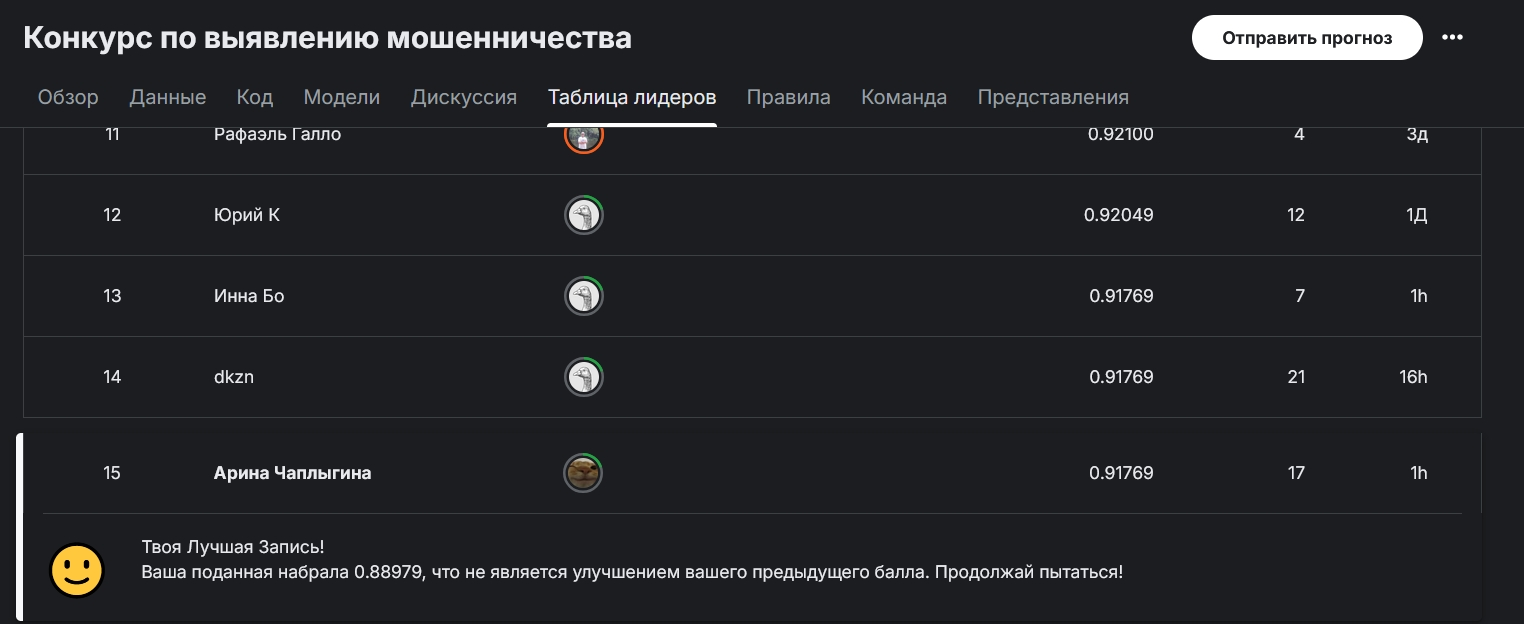